# 03 – State Transition Scoring (Configurable Disease → Target)

This notebook takes the symbol-indexed consensus matrix from **02_consensus_building.ipynb** and:

1. Loads a **perturbation state-space** (genes × perturbagens).
2. Defines a **disease vector (D)** and a **target attractor (T)** from MSigDB Hallmark
   or other gene sets.
3. Scores each perturbation `p` by its ability to move D toward T:
   \[
   \text{score}(p) = \cos(D + p, T)
   \]
4. Optionally evaluates **sequential perturbations** (p1 → p2).
5. Generates ranked tables and visualizations.

🔧 The disease and target programs are controlled via a small config cell,
so we can swap **EMT → MET** to, e.g., **NRF2-high → balanced**, **MYC-high → low**, etc.


# 1. Import

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import gseapy as gp

sns.set(style="whitegrid")

# -----------------------------------------------------------------
# Paths
# -----------------------------------------------------------------
PROJECT_ROOT = Path(
    r"C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator"
).resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "EMT_MET_MCF7"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PROCESSED:", DATA_PROCESSED)
print("RESULTS_DIR:", RESULTS_DIR)

# -----------------------------------------------------------------
# CONFIG: choose cell/context + disease/target programs
# -----------------------------------------------------------------
CELL_LINE = "MCF7"
TIME_LABEL = "24h"
PERT_TYPE = "trt_cp"

# Consensus file produced by Notebook 2
CONSENSUS_SYMBOL_FILE = DATA_PROCESSED / f"consensus_{CELL_LINE}_{TIME_LABEL}_{PERT_TYPE}_pert_iname_SYMBOL.csv"

# ---- DISEASE/TARGET DEFINITIONS (SWAPPABLE) ----

# 1) EMT → MET (current project)
DISEASE_NAME  = "EMT"
DISEASE_MSIGDB_KEY_PATTERN = "EPITHELIAL MESENCHYMAL TRANSITION"

TARGET_NAME   = "Epithelial/MET"
TARGET_MSIGDB_PATTERNS = ["APICAL SURFACE", "APICAL_JUNCTION", "APICAL JUNCTION"]

print(f"Disease program: {DISEASE_NAME}  (MSigDB pattern: '{DISEASE_MSIGDB_KEY_PATTERN}')")
print(f"Target program : {TARGET_NAME}   (MSigDB patterns: {TARGET_MSIGDB_PATTERNS})")


PROJECT_ROOT: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator
DATA_PROCESSED: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\data\processed
RESULTS_DIR: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\results\EMT_MET_MCF7
Disease program: EMT  (MSigDB pattern: 'EPITHELIAL MESENCHYMAL TRANSITION')
Target program : Epithelial/MET   (MSigDB patterns: ['APICAL SURFACE', 'APICAL_JUNCTION', 'APICAL JUNCTION'])


# 2. Load consensus matrix from Notebook 2

In [2]:
consensus_df_symbol = pd.read_csv(CONSENSUS_SYMBOL_FILE, index_col=0)
print("consensus_df_symbol shape (genes x perturbagens):", consensus_df_symbol.shape)
consensus_df_symbol.head()


consensus_df_symbol shape (genes x perturbagens): (12328, 1732)


,aminoguanidine,pritelivir,batimastat,CX-516,aminoglutethimide,oxaprozin,physostigmine,blonanserin,zaldaride,bortezomib,...,ZM-447439,SB-239063,MGCD-265,ALW-II-38-3,JNK-IN-5A,KIN001-127,serdemetan,KIN001-055,tie2-kinase-inhibitor,KI-20227
gene_symbol,,,,,,,,,,,,,,,,,,,,,
A1CF,0.449215,0.586641,-0.011569,0.202055,-0.119193,-0.452604,0.239270,0.177995,-0.210022,0.021482,...,0.372903,0.360370,-0.336601,-0.346386,0.088627,-0.336593,-0.182751,0.160962,-0.326134,-0.142001
A2M,0.500422,0.250143,-0.138603,0.491378,0.278176,0.037623,0.104261,-0.061826,-0.009395,0.673634,...,-0.230065,0.273643,-0.633439,-0.585802,-0.250798,-0.385820,-0.341995,0.134646,-0.074654,0.057420
A4GALT,-0.206287,0.253082,-0.059885,-0.253891,-0.194038,0.235557,-0.255651,-0.572775,-0.023381,-0.404510,...,0.750439,-0.050605,-0.290036,-0.406287,-0.862345,0.437501,0.105938,0.992216,0.037018,-0.447205
A4GNT,0.529682,0.278898,0.239876,0.489900,0.614708,0.025526,0.167883,0.006459,-0.164718,0.891150,...,0.270477,0.319873,-0.325588,-0.494282,-0.218474,-0.185898,-0.338788,0.315762,-0.157668,0.005486
AAAS,0.048544,0.529630,-0.082747,-0.240120,0.583073,0.716894,-0.296784,0.092532,0.353173,-0.411496,...,-0.365563,-0.124800,-0.189876,0.095806,0.312672,0.234723,-0.014361,1.743255,-0.219654,0.140098


# 3. Fetching Hallmark gene sets

In [3]:
# Load MSigDB Hallmark collection
hallmark_sets = gp.get_library(name="MSigDB_Hallmark_2020", organism="Human")
print("Loaded Hallmark sets:", len(hallmark_sets))

# Disease set: find key containing DISEASE_MSIGDB_KEY_PATTERN
disease_key = next(
    (k for k in hallmark_sets.keys() if DISEASE_MSIGDB_KEY_PATTERN in k.upper()),
    None
)
print("Disease MSigDB key:", disease_key)

disease_genes = hallmark_sets[disease_key]
disease_series = pd.Series(1.0, index=pd.Index(disease_genes, name="gene_symbol"))
print(f"{DISEASE_NAME} genes:", len(disease_series))

# Target set: first match among patterns
target_key = None
for pattern in TARGET_MSIGDB_PATTERNS:
    target_key = next((k for k in hallmark_sets.keys() if pattern in k.upper()), None)
    if target_key:
        break

print("Target MSigDB key:", target_key)

target_genes = hallmark_sets[target_key]
target_series = pd.Series(1.0, index=pd.Index(target_genes, name="gene_symbol"))
print(f"{TARGET_NAME} genes:", len(target_series))


Loaded Hallmark sets: 50
Disease MSigDB key: Epithelial Mesenchymal Transition
EMT genes: 200
Target MSigDB key: Apical Surface
Epithelial/MET genes: 44


# 4 Building disease & target vectors in the LINCS space

In [4]:
space_genes = consensus_df_symbol.index.astype(str)

disease_vec = pd.Series(0.0, index=space_genes)
target_vec  = pd.Series(0.0, index=space_genes)

# Mark genes present in the space
disease_vec[disease_vec.index.isin(disease_series.index)] = 1.0
target_vec[target_vec.index.isin(target_series.index)]    = 1.0

print(f"{DISEASE_NAME} genes present in space:", int(disease_vec.sum()))
print(f"{TARGET_NAME} genes present in space:", int(target_vec.sum()))


EMT genes present in space: 194
Epithelial/MET genes present in space: 33


# 5. Single-step scoring

In [8]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
def cos(a: pd.Series, b: pd.Series) -> float:
    return float(cosine_similarity(
        a.values.reshape(1, -1),
        b.values.reshape(1, -1)
    ))

space_genes = consensus_df_symbol.index.astype(str)

results = []
for pert in consensus_df_symbol.columns:
    effect = consensus_df_symbol[pert].reindex(space_genes).fillna(0.0)
    new_state = disease_vec + effect
    score = cos(new_state, target_vec)
    results.append((pert, score))

results_df = pd.DataFrame(results, columns=["perturbagen", "cosine_to_target"])
results_df = results_df.sort_values("cosine_to_target", ascending=False)

print("Single-step results:", results_df.shape)
results_df.head(10)


C:\Users\Physi\AppData\Local\Temp\ipykernel_8864\492997159.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(
C:\Users\Physi\AppData\Local\Temp\ipykernel_8864\492997159.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(
C:\Users\Physi\AppData\Local\Temp\ipykernel_8864\492997159.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(
C:\Users\Physi\AppData\Local\Temp\ipyker

Single-step results: (1732, 2)


C:\Users\Physi\AppData\Local\Temp\ipykernel_8864\492997159.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(
C:\Users\Physi\AppData\Local\Temp\ipykernel_8864\492997159.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(
C:\Users\Physi\AppData\Local\Temp\ipykernel_8864\492997159.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(
C:\Users\Physi\AppData\Local\Temp\ipyker

,perturbagen,cosine_to_target
1031,AKT-inhibitor-1-2,0.045475
589,UK-383367,0.045283
452,flutamide,0.043706
955,AVN-944,0.043512
978,raloxifene,0.043102
235,LCL-161,0.043046
632,drospirenone,0.042674
700,gemifloxacin,0.042571
206,KW-2449,0.042383
1181,CP-724714,0.041009


In [7]:

single_out = RESULTS_DIR / f"{CELL_LINE}_{DISEASE_NAME}_to_{TARGET_NAME}_single_step.csv"
# 2. Create the folder if it doesn't exist
# parents=True: creates any missing folders in the hierarchy (e.g., results/2024/output)
# exist_ok=True: prevents an error if the folder already exists
single_out.parent.mkdir(parents=True, exist_ok=True)

# 3. Save the file
results_df.to_csv(single_out, index=False)
print("Saved:", single_out)

Saved: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\results\EMT_MET_MCF7\MCF7_EMT_to_Epithelial\MET_single_step.csv


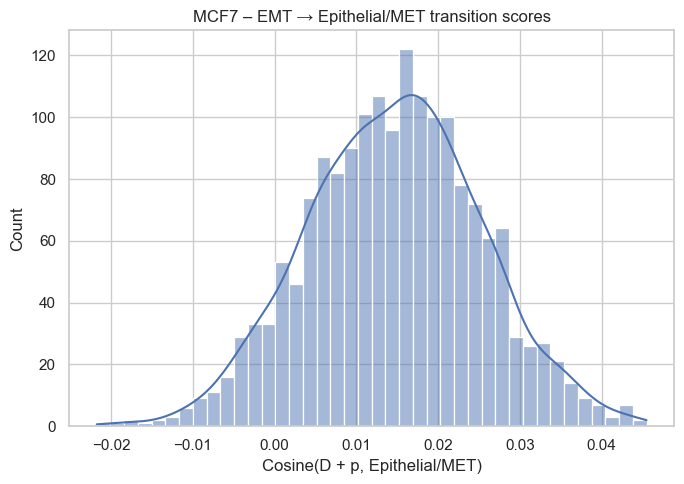

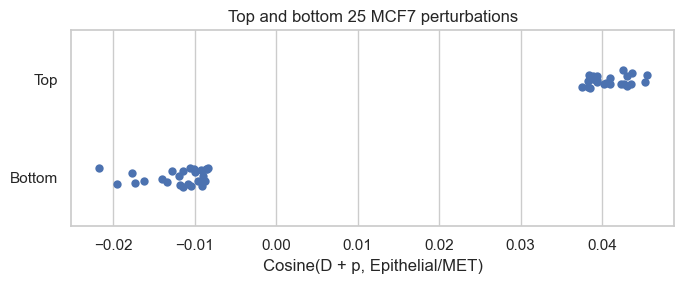

In [9]:
# ==== Plot 1: Score distribution + top/bottom highlights ====

plt.figure(figsize=(7,5))
sns.histplot(results_df["cosine_to_target"], bins=40, kde=True)
plt.xlabel(f"Cosine(D + p, {TARGET_NAME})")
plt.ylabel("Count")
plt.title(f"{CELL_LINE} – {DISEASE_NAME} → {TARGET_NAME} transition scores")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{CELL_LINE}_{DISEASE_NAME}_to_{TARGET_NAME}_score_hist.png", dpi=300)
plt.show()

# Strip for top and bottom 25
n = 25
top_n = results_df.head(n).assign(group="Top")
bottom_n = results_df.tail(n).assign(group="Bottom")
tb = pd.concat([top_n, bottom_n], ignore_index=True)

plt.figure(figsize=(7,3))
sns.stripplot(
    data=tb,
    x="cosine_to_target",
    y="group",
    jitter=0.1,
    size=6
)
plt.xlabel(f"Cosine(D + p, {TARGET_NAME})")
plt.ylabel("")
plt.title(f"Top and bottom {n} {CELL_LINE} perturbations")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{CELL_LINE}_{DISEASE_NAME}_to_{TARGET_NAME}_top_bottom_strip.png", dpi=300)
plt.show()


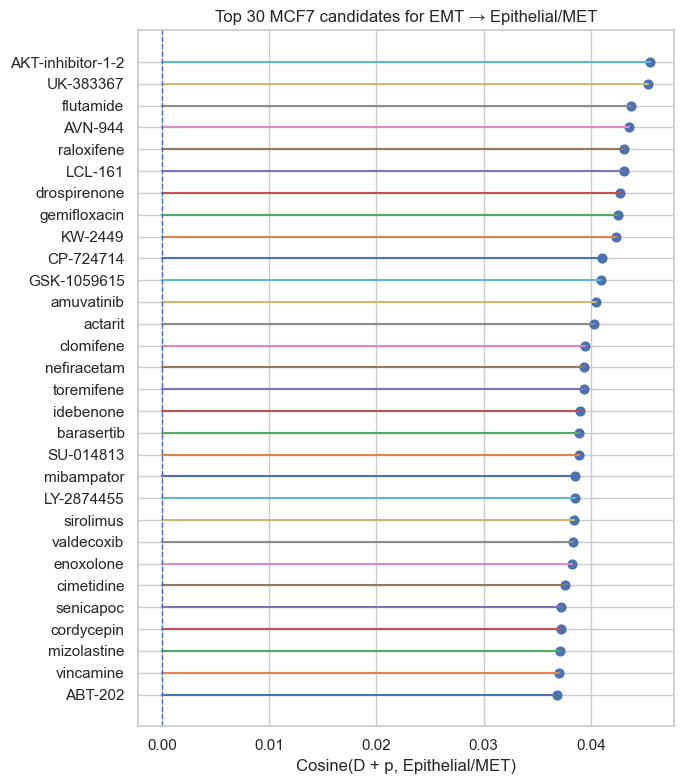

In [10]:
# ==== Plot 2: Lollipop plot of top 30 candidates ====

top30 = results_df.head(30).copy()
top30 = top30.sort_values("cosine_to_target")  # for nicer vertical order

plt.figure(figsize=(7,8))

y = np.arange(len(top30))
x = top30["cosine_to_target"].values

# stems
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.plot([0, xi], [yi, yi], linewidth=1.5)

# markers
plt.scatter(x, y, s=40)

plt.yticks(y, top30["perturbagen"])
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel(f"Cosine(D + p, {TARGET_NAME})")
plt.title(f"Top 30 {CELL_LINE} candidates for {DISEASE_NAME} → {TARGET_NAME}")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{CELL_LINE}_{DISEASE_NAME}_to_{TARGET_NAME}_top30_lollipop.png", dpi=300)
plt.show()


C:\Users\Physi\AppData\Local\Temp\ipykernel_8864\1915747106.py:28: UserWarning: Glyph 8746 (\N{UNION}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Physi\AppData\Local\Temp\ipykernel_8864\1915747106.py:29: UserWarning: Glyph 8746 (\N{UNION}) missing from font(s) Arial.
  plt.savefig(RESULTS_DIR / f"{CELL_LINE}_{DISEASE_NAME}_to_{TARGET_NAME}_top{top_k}_gene_heatmap.png", dpi=300)
C:\Users\Physi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8746 (\N{UNION}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


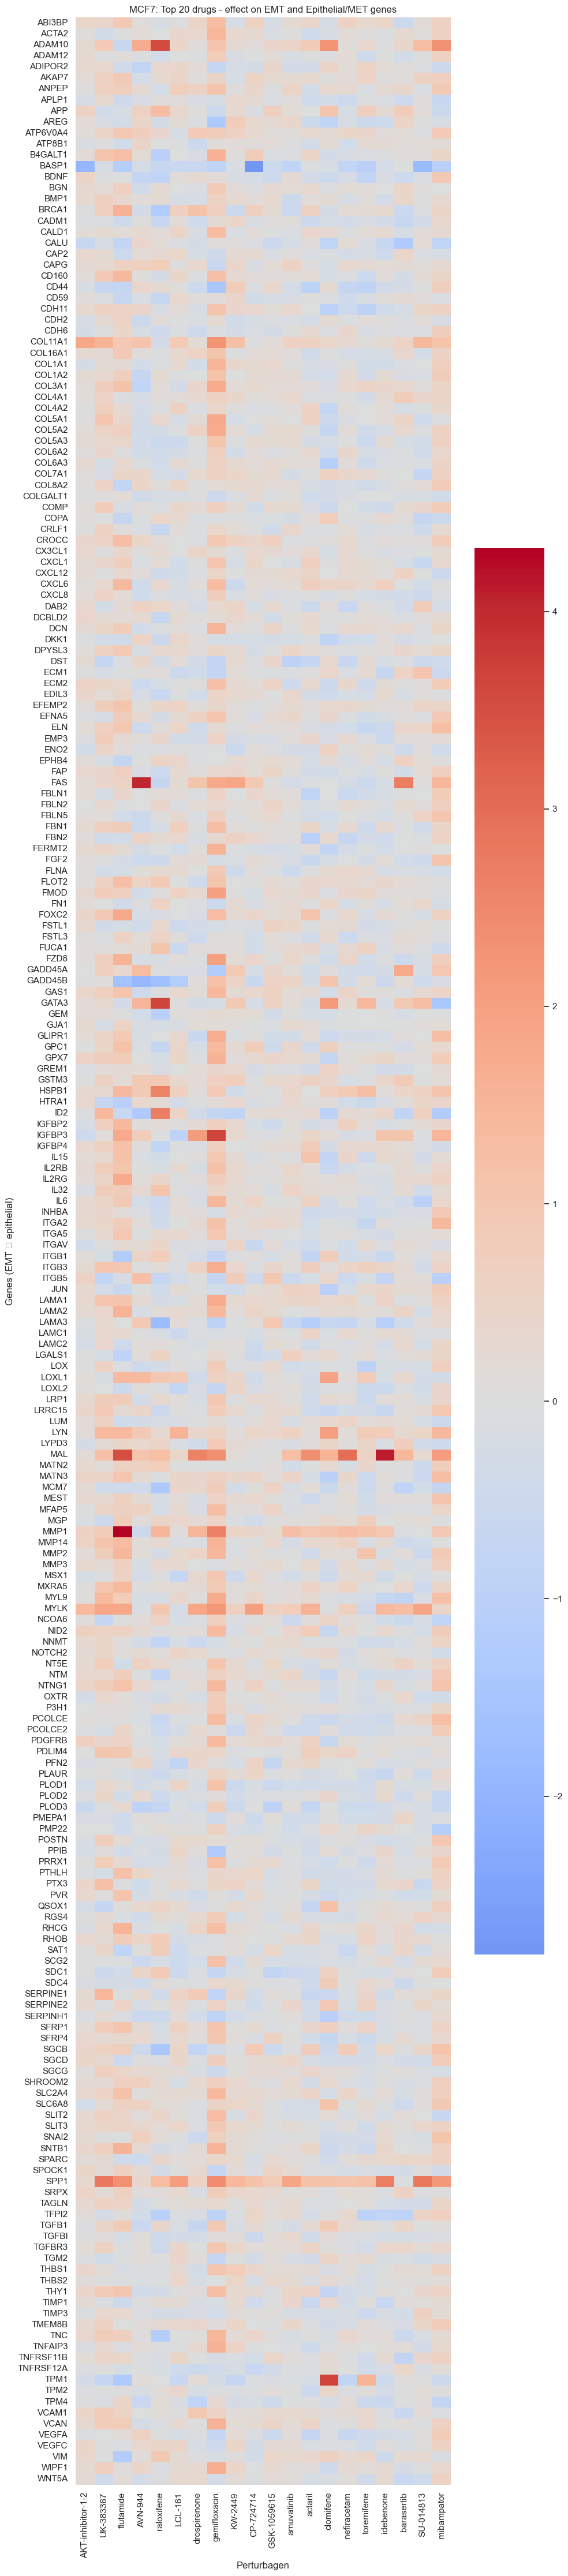

In [12]:
# ==== Plot 3: Heatmap of top 20 drugs × EMT+EPI genes ====

# Use the gene sets we already had:
# disease_series (EMT genes), target_series (epithelial genes)

top_k = 20
top_drugs = results_df.head(top_k)["perturbagen"].tolist()

# Union of disease and target genes present in our space
space_genes = consensus_df_symbol.index.astype(str)
heat_genes = sorted(
    set(disease_series.index).union(set(target_series.index))
    .intersection(space_genes)
)

heatmat = consensus_df_symbol.loc[heat_genes, top_drugs]

plt.figure(figsize=(10, max(6, len(heat_genes) * 0.2)))
sns.heatmap(
    heatmat,
    center=0,
    cmap="coolwarm",
    yticklabels=True
)
plt.xlabel("Perturbagen")
plt.ylabel("Genes (EMT ∪ epithelial)")
plt.title(f"{CELL_LINE}: Top {top_k} drugs - effect on {DISEASE_NAME} and {TARGET_NAME} genes")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{CELL_LINE}_{DISEASE_NAME}_to_{TARGET_NAME}_top{top_k}_gene_heatmap.png", dpi=300)
plt.show()


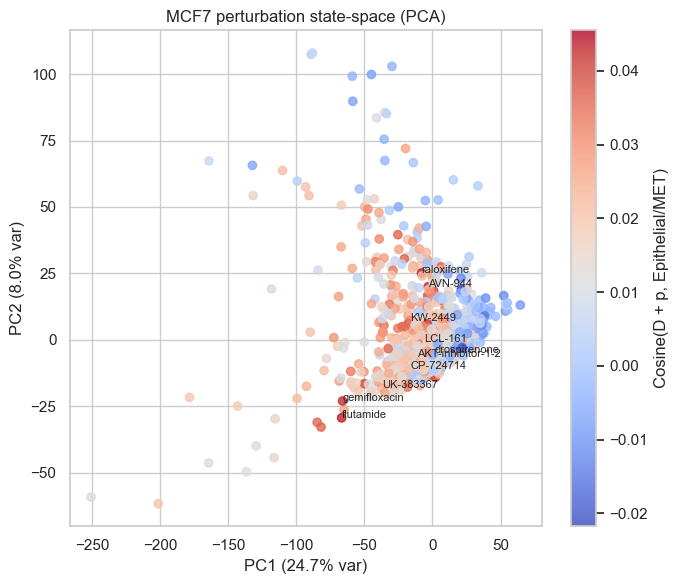

In [13]:
# ==== Plot 4: PCA with labels for top hits ====

X = consensus_df_symbol.T  # perturbagens x genes

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(
    X_pca,
    index=X.index,
    columns=["PC1", "PC2"]
).join(
    results_df.set_index("perturbagen")
)

plt.figure(figsize=(7,6))
sc = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cosine_to_target"],
    cmap="coolwarm",
    alpha=0.8
)
plt.colorbar(sc, label=f"Cosine(D + p, {TARGET_NAME})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title(f"{CELL_LINE} perturbation state-space (PCA)")

# label top N drugs directly on plot
N_LABEL = 10
for name, row in pca_df.sort_values("cosine_to_target", ascending=False).head(N_LABEL).iterrows():
    plt.text(row["PC1"], row["PC2"], name, fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{CELL_LINE}_{DISEASE_NAME}_to_{TARGET_NAME}_PCA_labeled.png", dpi=300)
plt.show()


In [15]:
# ================================================================
# Sequential Perturbation Analysis (p1 → p2)
# ================================================================
# For each p1, compute D1 = D + p1
# Then for each p2, compute score = cos(D1 + p2, T)
# ================================================================

MAX_P1 = 50  # number of best p1 candidates to consider
MAX_P2 = 50  # number of best p2 candidates to consider

# Take the top P1 candidates from single-step
p1_candidates = results_df.head(MAX_P1)["perturbagen"].tolist()
p2_candidates = results_df.head(MAX_P2)["perturbagen"].tolist()

comb_results = []

for p1 in p1_candidates:
    p1_vec = consensus_df_symbol[p1].reindex(space_genes).fillna(0.0)
    D1 = disease_vec + p1_vec
    
    for p2 in p2_candidates:
        p2_vec = consensus_df_symbol[p2].reindex(space_genes).fillna(0.0)
        score = cos(D1 + p2_vec, target_vec)
        comb_results.append((p1, p2, score))

comb_df = pd.DataFrame(comb_results, columns=["p1", "p2", "cosine_to_target"])
comb_df = comb_df.sort_values("cosine_to_target", ascending=False)

print("Sequential combos found:", comb_df.shape)
comb_df.head(10)


C:\Users\Physi\AppData\Local\Temp\ipykernel_8864\492997159.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(
C:\Users\Physi\AppData\Local\Temp\ipykernel_8864\492997159.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(
C:\Users\Physi\AppData\Local\Temp\ipykernel_8864\492997159.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(
C:\Users\Physi\AppData\Local\Temp\ipyker

Sequential combos found: (2500, 3)


C:\Users\Physi\AppData\Local\Temp\ipykernel_8864\492997159.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(
C:\Users\Physi\AppData\Local\Temp\ipykernel_8864\492997159.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(
C:\Users\Physi\AppData\Local\Temp\ipykernel_8864\492997159.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(cosine_similarity(
C:\Users\Physi\AppData\Local\Temp\ipyker

,p1,p2,cosine_to_target
53,UK-383367,AVN-944,0.058857
151,AVN-944,UK-383367,0.058857
162,AVN-944,actarit,0.058181
603,actarit,AVN-944,0.058181
54,UK-383367,raloxifene,0.057509
201,raloxifene,UK-383367,0.057509
89,UK-383367,KW-2478,0.057117
1951,KW-2478,UK-383367,0.057117
651,clomifene,UK-383367,0.057034
63,UK-383367,clomifene,0.057034


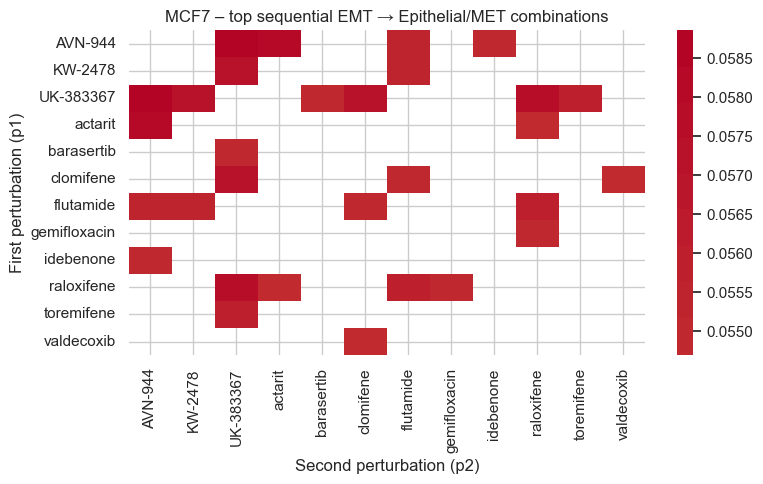

In [16]:
# ==== Plot 5: Top combo heatmap (p1, p2) ====

# Assuming comb_df with columns ["p1", "p2", "cosine_to_target"]
top_pairs = comb_df.head(30).copy()

pivot = top_pairs.pivot(index="p1", columns="p2", values="cosine_to_target")

plt.figure(figsize=(8, max(5, pivot.shape[0] * 0.4)))
sns.heatmap(pivot, annot=False, cmap="coolwarm", center=0)
plt.xlabel("Second perturbation (p2)")
plt.ylabel("First perturbation (p1)")
plt.title(f"{CELL_LINE} – top sequential {DISEASE_NAME} → {TARGET_NAME} combinations")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{CELL_LINE}_{DISEASE_NAME}_to_{TARGET_NAME}_top_combos_heatmap.png", dpi=300)
plt.show()


In [17]:
combo_out = RESULTS_DIR / f"{CELL_LINE}_{DISEASE_NAME}_to_{TARGET_NAME}_sequential_combos.csv"
comb_df.to_csv(combo_out, index=False)
print("Saved sequential combos to:", combo_out)


Saved sequential combos to: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\results\EMT_MET_MCF7\MCF7_EMT_to_Epithelial\MET_sequential_combos.csv


In [18]:
# attach p1 single-step and p2 single-step scores
ss = results_df.set_index("perturbagen")["cosine_to_target"]

comb_df["p1_single"] = comb_df["p1"].map(ss)
comb_df["p2_single"] = comb_df["p2"].map(ss)

comb_df["gain_over_p1"] = comb_df["cosine_to_target"] - comb_df["p1_single"]
comb_df["gain_over_p2"] = comb_df["cosine_to_target"] - comb_df["p2_single"]

# Big jump combos
big_gain = comb_df.sort_values("gain_over_p1", ascending=False).head(20)
big_gain


,p1,p2,cosine_to_target,p1_single,p2_single,gain_over_p1,gain_over_p2
1951,KW-2478,UK-383367,0.057117,0.035906,0.045283,0.021211,0.011835
1952,KW-2478,flutamide,0.055533,0.035906,0.043706,0.019627,0.011827
2053,amoxapine,AVN-944,0.053862,0.035687,0.043512,0.018175,0.010350
603,actarit,AVN-944,0.058181,0.040303,0.043512,0.017878,0.014669
651,clomifene,UK-383367,0.057034,0.039415,0.045283,0.017619,0.011751
1957,KW-2478,gemifloxacin,0.053313,0.035906,0.042571,0.017406,0.010742
1203,cimetidine,AVN-944,0.054565,0.037586,0.043512,0.016979,0.011053
1454,ABT-202,raloxifene,0.053774,0.036833,0.043102,0.016940,0.010672
2451,ciprofloxacin,UK-383367,0.052044,0.035104,0.045283,0.016940,0.006761
751,toremifene,UK-383367,0.055898,0.039378,0.045283,0.016521,0.010616


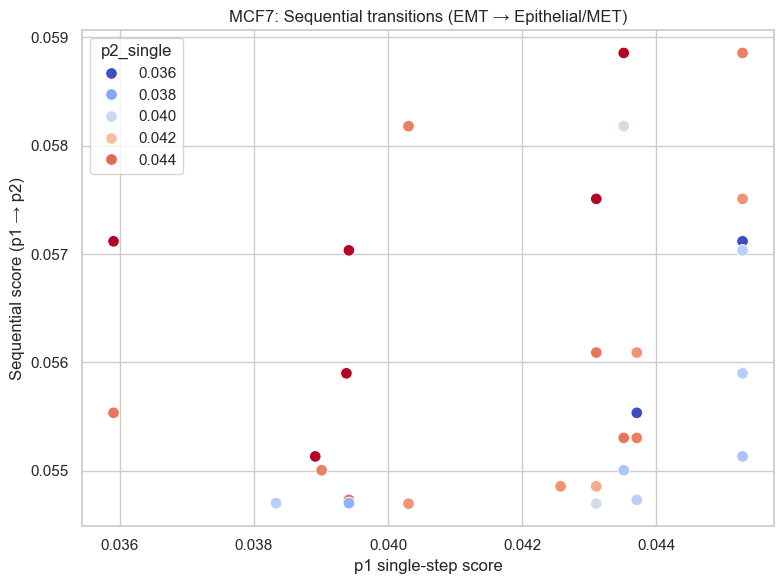

In [19]:
plt.figure(figsize=(8,6))
subset_plot = comb_df.head(30)

sns.scatterplot(
    data=subset_plot,
    x="p1_single",
    y="cosine_to_target",
    hue="p2_single",
    palette="coolwarm",
    s=70
)
plt.xlabel("p1 single-step score")
plt.ylabel("Sequential score (p1 → p2)")
plt.title(f"{CELL_LINE}: Sequential transitions ({DISEASE_NAME} → {TARGET_NAME})")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{CELL_LINE}_{DISEASE_NAME}_to_{TARGET_NAME}_sequential_scatter.png", dpi=300)
plt.show()
